# Spatial protocluster generation

Extends `protoclusterGen.ipynb` by giving the sampled protostars positions. The positions follow a 3D log-normal fractional Brownian motion (fBm) density field with fractal dimension $D = 2.4$.

In [11]:
from ocotillopmf import PowerLawAccrete, PMF
from ocotillopmf.spatial import Spatial
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmasher as cmr

In [12]:
#Cluster parameters
Nstar = 1000   #number of protostars
D = 2.4        #fractal dimension of the fBm
ndim = 3       #Euclidean dimension
L = 10.0        #box size; positions lie in [-L/2, L/2]
sigma = 1.5

In [13]:
#Sample positions: the log-fBm is used as a 3D PDF and Nstar stars are drawn from it
spatialObj = Spatial(seed=11235813)
x, y, z = spatialObj.makeStellarCluster(nstar=Nstar, ndim=ndim, D=D, L=L, sigma=sigma, recenter=True)

grid, spatProb = spatialObj.makeFBM(ndim=ndim, D=D, L=L, scale=sigma)
spatProb = spatialObj.recenterField(spatProb)

In [14]:
#Assign each protostar a mass, using the same tapered turbulent core model as protoclusterGen.ipynb
plawObj = PowerLawAccrete(0.5, 0.75, 3.6E-5, deltan1 = 1.0)
pmfObj = PMF(plawObj)
m_arr, mf_arr = pmfObj.PhiInvertSample(N=Nstar)

In [15]:
#Plot styling shared by the figures below. Colour and marker area both scale with log mass

vmin, vmax = -1.0, np.log10(8.0)
massCmap = cmr.get_sub_cmap(cmr.wildfire, start = 0.1, stop = 0.9)
logm = np.log10(m_arr)
starSize = 5 + 75 * np.clip((logm - vmin) / (vmax - vmin), 0, 1)**1.5
drawOrder = np.argsort(m_arr)  #lightest first, so massive stars are drawn on top

def plotStars(ax, a, b, **kwargs):
    return ax.scatter(a[drawOrder], b[drawOrder], c=logm[drawOrder], 
                      s=starSize[drawOrder], cmap=massCmap, 
                      vmin=vmin, vmax=vmax, linewidths=0, **kwargs)

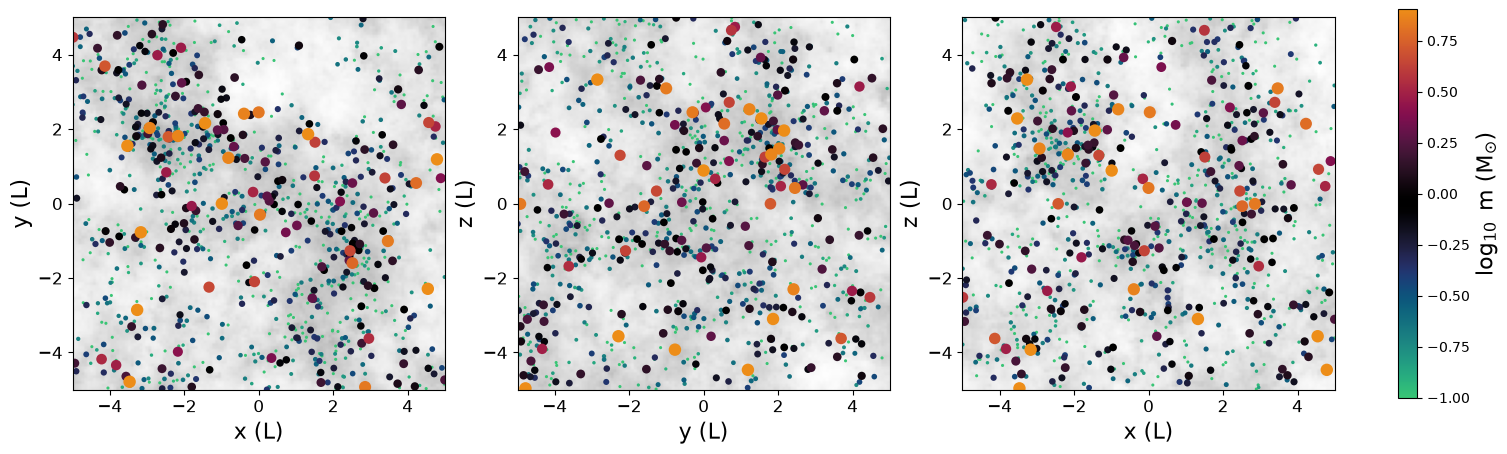

In [16]:
#Projections of the cluster onto the x-y, y-z and x-z planes, colored by protostellar mass
planes = [(x, y, "x", "y", 2), (y, z, "y", "z", 0), (x, z, "x", "z", 1)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, (a, b, la, lb, si) in zip(axes, planes):
    sc = plotStars(ax, a, b)

    pdfProj = np.sum(spatProb, axis=si)
    ax.imshow(pdfProj.T, extent=[-L/2., L/2., -L/2., L/2.], cmap='Greys', alpha=0.3333, origin='lower', norm=colors.LogNorm())
    
    ax.set_xlim(-L/2, L/2)
    ax.set_ylim(-L/2, L/2)
    ax.set_aspect('equal')
    ax.set_xlabel(f"{la} (L)", fontsize=16)
    ax.set_ylabel(f"{lb} (L)", fontsize=16)
    ax.tick_params(which='both', axis='both', labelsize=12)
cb = fig.colorbar(sc, ax=axes, shrink=0.8)
cb.set_label(r"$\log_{10}$ m (M$_{\odot}$)", fontsize=16)
plt.show()

## Mass segregation

Impose primordial mass segregation with the Baumgardt et al. (2008) scheme used in McLuster. Positions are ranked from most to least bound, and stars are swapped in from heaviest to lightest. $S = 0$ gives no segregation, and $S \to 1$ puts the most massive stars in the most bound positions.

In [17]:
#Same seed, so the fBm and the set of positions match the unsegregated cluster above;
#only which protostar sits at which position changes. Star i has mass m_arr[i].
S = 0.75
spatialObj = Spatial(seed=11235813)
xs, ys, zs = spatialObj.makeStellarCluster(nstar=Nstar, ndim=ndim, D=D, L=L, sigma=sigma,massSegregate=True, S=S, masses=m_arr, recenter=True)

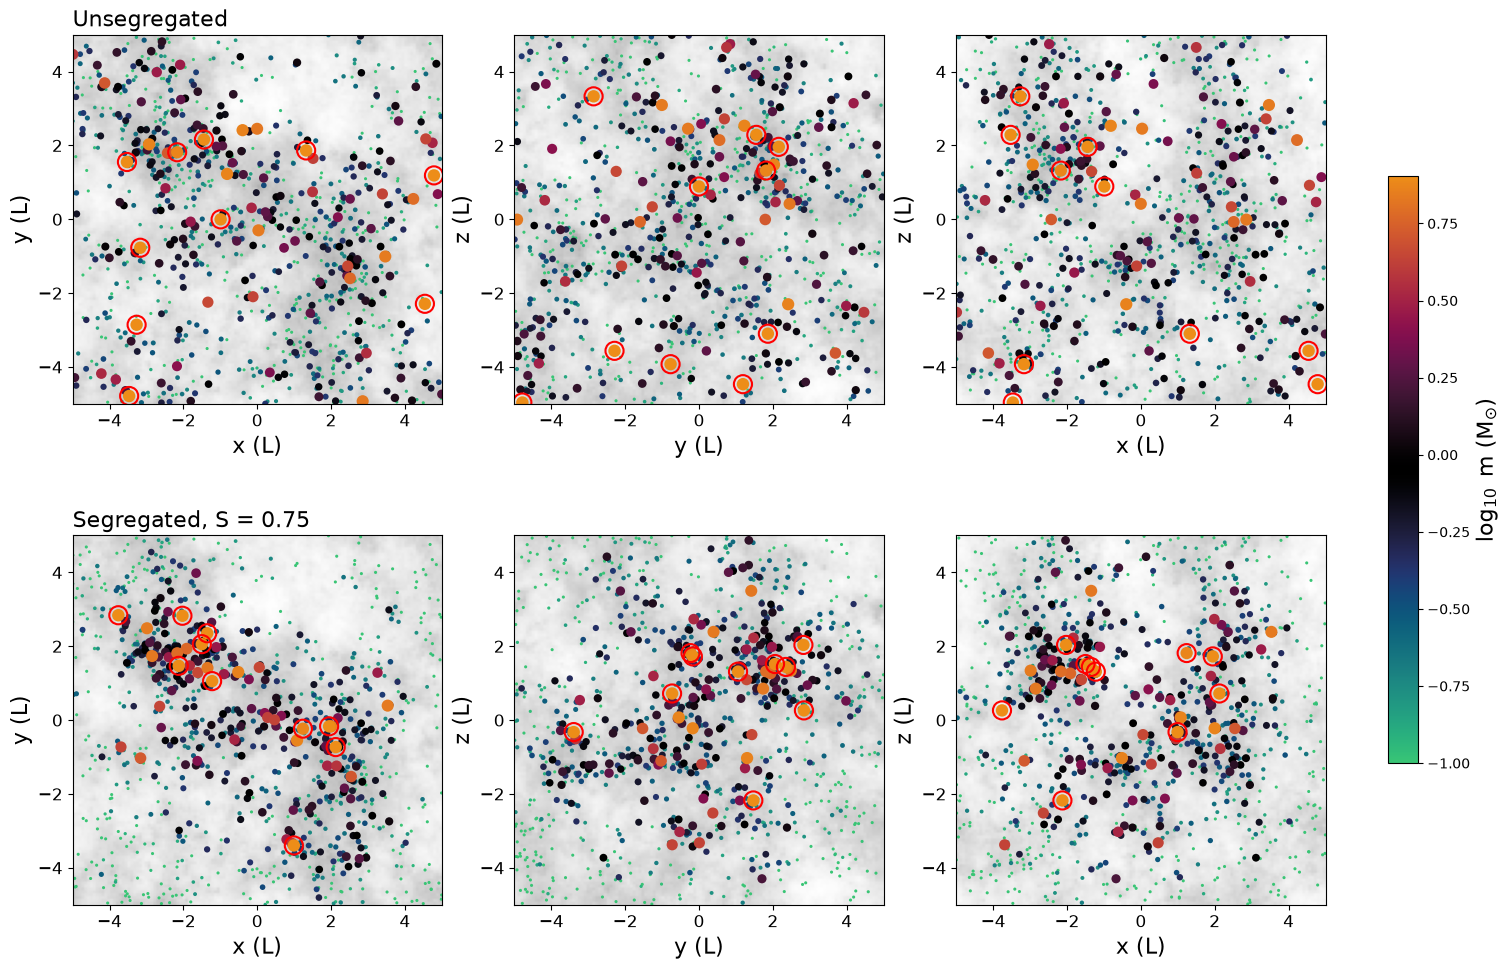

In [18]:
#Compare the unsegregated (top) and segregated (bottom) clusters; the 10 most massive protostars are circled in red
top10 = np.argsort(-m_arr)[:10]
clusters = [((x, y, z), "Unsegregated"), ((xs, ys, zs), f"Segregated, S = {S}")]

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for row, ((cx, cy, cz), title) in zip(axes, clusters):
    planes = [(cx, cy, "x", "y", 2), (cy, cz, "y", "z", 0), (cx, cz, "x", "z", 1)]
    for ax, (a, b, la, lb, si) in zip(row, planes):
        sc = plotStars(ax, a, b)
        ax.scatter(a[top10], b[top10], s=starSize[top10] + 90, facecolors='none', edgecolors='r', lw=1.5)

        pdfProj = np.sum(spatProb, axis=si)
        ax.imshow(pdfProj.T, extent=[-L/2., L/2., -L/2., L/2.], cmap='Greys', alpha=0.3333, origin='lower', norm=colors.LogNorm())
        
        ax.set_xlim(-L/2, L/2)
        ax.set_ylim(-L/2, L/2)
        ax.set_aspect('equal')
        ax.set_xlabel(f"{la} (L)", fontsize=16)
        ax.set_ylabel(f"{lb} (L)", fontsize=16)
        ax.tick_params(which='both', axis='both', labelsize=12)
    row[0].set_title(title, fontsize=16, loc='left')
cb = fig.colorbar(sc, ax=axes, shrink=0.6)
cb.set_label(r"$\log_{10}$ m (M$_{\odot}$)", fontsize=16)
plt.show()

In [19]:
#Quantify with the mass segregation ratio of Allison et al. (2009): the mean minimum spanning tree (MST)
#length of random sets of 10 stars over that of the 10 most massive. Lambda_MSR ~ 1 means no segregation.
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform


def mstLength(pos):
    return minimum_spanning_tree(squareform(pdist(pos))).sum()

def lambdaMSR(pos, m, nmst=10, nrand=500):
    lrand = [mstLength(pos[np.random.choice(len(m), nmst, replace=False)]) for _ in range(nrand)]
    return np.mean(lrand) / mstLength(pos[np.argsort(-m)[:nmst]])

print(f"Unsegregated:  Lambda_MSR = {lambdaMSR(np.column_stack([x, y, z]), m_arr):.2f}")
print(f"S = {S}:      Lambda_MSR = {lambdaMSR(np.column_stack([xs, ys, zs]), m_arr):.2f}")

Unsegregated:  Lambda_MSR = 0.94
S = 0.75:      Lambda_MSR = 1.86


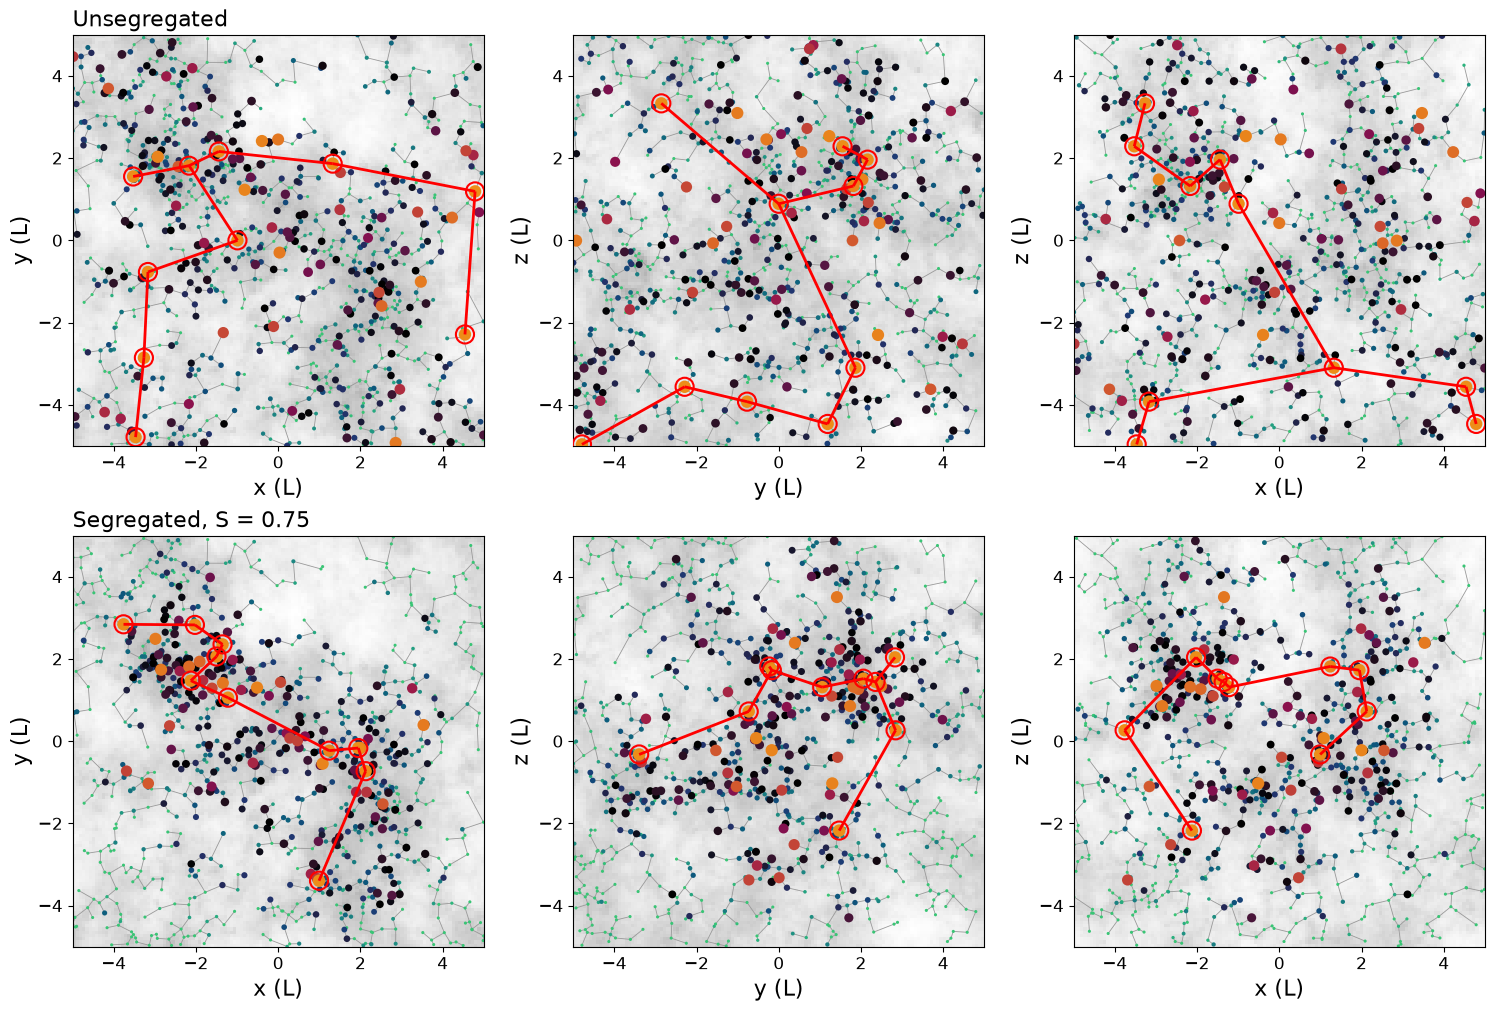

In [20]:
#Projected minimum spanning trees in each plane: the MST of the full cluster (grey) and the MST
#of the 10 most massive protostars (red), which is the tree Lambda_MSR compares against random sets
from matplotlib.collections import LineCollection


def mstSegments(pos):
    #Line segments ((x0, y0), (x1, y1)) for each edge of the MST of pos
    i, j = minimum_spanning_tree(squareform(pdist(pos))).nonzero()
    return np.stack([pos[i], pos[j]], axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for row, ((cx, cy, cz), title) in zip(axes, clusters):
    planes = [(cx, cy, "x", "y", 2), (cy, cz, "y", "z", 0), (cx, cz, "x", "z", 1)]
    for ax, (a, b, la, lb, si) in zip(row, planes):
        pos2d = np.column_stack([a, b])
        ax.add_collection(LineCollection(mstSegments(pos2d), colors='0.6', lw=0.6, zorder=1))
        plotStars(ax, a, b, zorder=2)
        ax.add_collection(LineCollection(mstSegments(pos2d[top10]), colors='r', lw=2, zorder=3))
        ax.scatter(a[top10], b[top10], s=starSize[top10] + 90, facecolors='none', edgecolors='r', lw=1.5, zorder=4)

        pdfProj = np.sum(spatProb, axis=si)
        ax.imshow(pdfProj.T, extent=[-L/2., L/2., -L/2., L/2.], cmap='Greys', alpha=0.3333, origin='lower', norm=colors.LogNorm())
        
        ax.set_xlim(-L/2, L/2)
        ax.set_ylim(-L/2, L/2)
        ax.set_aspect('equal')
        ax.set_xlabel(f"{la} (L)", fontsize=16)
        ax.set_ylabel(f"{lb} (L)", fontsize=16)
        ax.tick_params(which='both', axis='both', labelsize=12)
    row[0].set_title(title, fontsize=16, loc='left')
plt.show()